# Hyperparameter Tuning

## Ames Housing Dataset — GridSearchCV, RandomizedSearchCV, and Optuna

**Dataset:** Ames Housing via `sklearn.datasets.fetch_openml` — same dataset
and preprocessing as notebooks 05 and 06. Target is log(SalePrice).

**Benchmark:** XGBoost with early stopping RMSE from notebook 06.

**Goal:** Understand the three main approaches to hyperparameter tuning —
exhaustive grid search, random search, and Bayesian optimisation with Optuna.
Each method makes a different tradeoff between search coverage, computation
time, and the intelligence of the search strategy.

Hyperparameter tuning is the last lever after feature engineering and model
selection. A well-tuned model on good features consistently outperforms a
poorly-tuned model on the same features — but tuning cannot compensate for
poor features or the wrong model family.

### Tech Stack

| Library | Purpose |
|---|---|
| pandas / numpy | Data handling |
| matplotlib / seaborn | Visualisation |
| scikit-learn | GridSearchCV, RandomizedSearchCV, cross-validation |
| xgboost | Primary model for tuning demonstrations |
| optuna | Bayesian hyperparameter optimisation |

## Setup and Imports

In [7]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    KFold,
    StratifiedKFold,
    RepeatedKFold,
    cross_val_score,
)
from sklearn.preprocessing import PowerTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from scipy.stats import uniform, randint

import xgboost as xgb
import optuna
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_contour,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use("seaborn-v0_8-whitegrid")

print("All imports successful.")
print(f"Optuna version:  {optuna.__version__}")
print(f"XGBoost version: {xgb.__version__}")

All imports successful.
Optuna version:  4.8.0
XGBoost version: 3.2.0


## Load and Prepare the Dataset

Same loading and preprocessing as notebooks 05 and 06. Preprocessed arrays
are built once here and reused across all tuning sections.

In [8]:
# Load
housing = fetch_openml(name="house_prices", version=1, as_frame=True)
df      = housing.frame.copy()

# Target
df["SalePrice_log"] = np.log1p(df["SalePrice"])
X = df.drop(columns=["SalePrice", "SalePrice_log", "Id"])
y = df["SalePrice_log"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature groups
numeric_cols     = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Preprocessor
numeric_transformer = Pipeline(steps=[
    ("imputer",     SimpleImputer(strategy="median")),
    ("transformer", PowerTransformer(method="yeo-johnson")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer,     numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f"X_train: {X_train.shape}  ->  processed: {X_train_processed.shape}")
print(f"X_test:  {X_test.shape}   ->  processed: {X_test_processed.shape}")

X_train: (1168, 79)  ->  processed: (1168, 286)
X_test:  (292, 79)   ->  processed: (292, 286)


In [10]:
# Ridge baseline
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_processed, y_train)
rmse_ridge = root_mean_squared_error(y_test, ridge.predict(X_test_processed))

# XGBoost default baseline
xgb_default = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbosity=0,
)
xgb_default.fit(X_train_processed, y_train)
rmse_xgb_default = root_mean_squared_error(
    y_test, xgb_default.predict(X_test_processed)
)

print(f"Ridge baseline RMSE:  {rmse_ridge:.4f}")
print(f"XGBoost default RMSE: {rmse_xgb_default:.4f}")

Ridge baseline RMSE:  0.1296
XGBoost default RMSE: 0.1349


## Why Hyperparameter Tuning Matters

Hyperparameters are settings that control model behaviour but are not learned
from data during training. The right values depend entirely on the dataset —
there are no universally optimal hyperparameters.

The impact of hyperparameters varies significantly:
- Some have large effect on performance (learning_rate, max_depth)
- Some have moderate effect (subsample, colsample_bytree)
- Some have minimal effect on most datasets (reg_alpha at small values)

Understanding which parameters matter most before searching saves significant
computation — a targeted search over impactful parameters outperforms an
exhaustive search over everything.

In [11]:
param_sweeps = {
    "max_depth":        [2, 3, 4, 5, 6, 7, 8],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
    "subsample":        [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha":        [0, 0.01, 0.1, 0.5, 1.0, 5.0],
    "reg_lambda":       [0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
}

sweep_results = {}

for param, values in param_sweeps.items():
    print(f"Sweeping {param}...")
    rmses = []
    for v in values:
        base_params = dict(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            verbosity=0,
        )
        base_params[param] = v
        m = xgb.XGBRegressor(**base_params)
        m.fit(X_train_processed, y_train)
        rmses.append(
            root_mean_squared_error(y_test, m.predict(X_test_processed))
        )
    sweep_results[param] = (values, rmses)
    best_val = values[np.argmin(rmses)]
    print(f"  best={best_val}  RMSE={min(rmses):.4f}")

print(f"\nSweep complete. Parameters swept: {list(sweep_results.keys())}")

Sweeping max_depth...
  best=3  RMSE=0.1293
Sweeping learning_rate...
  best=0.3  RMSE=0.1326
Sweeping subsample...
  best=0.7  RMSE=0.1298
Sweeping colsample_bytree...
  best=0.9  RMSE=0.1294
Sweeping reg_alpha...
  best=0.5  RMSE=0.1318
Sweeping reg_lambda...
  best=0.1  RMSE=0.1319

Sweep complete. Parameters swept: ['max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'reg_alpha', 'reg_lambda']


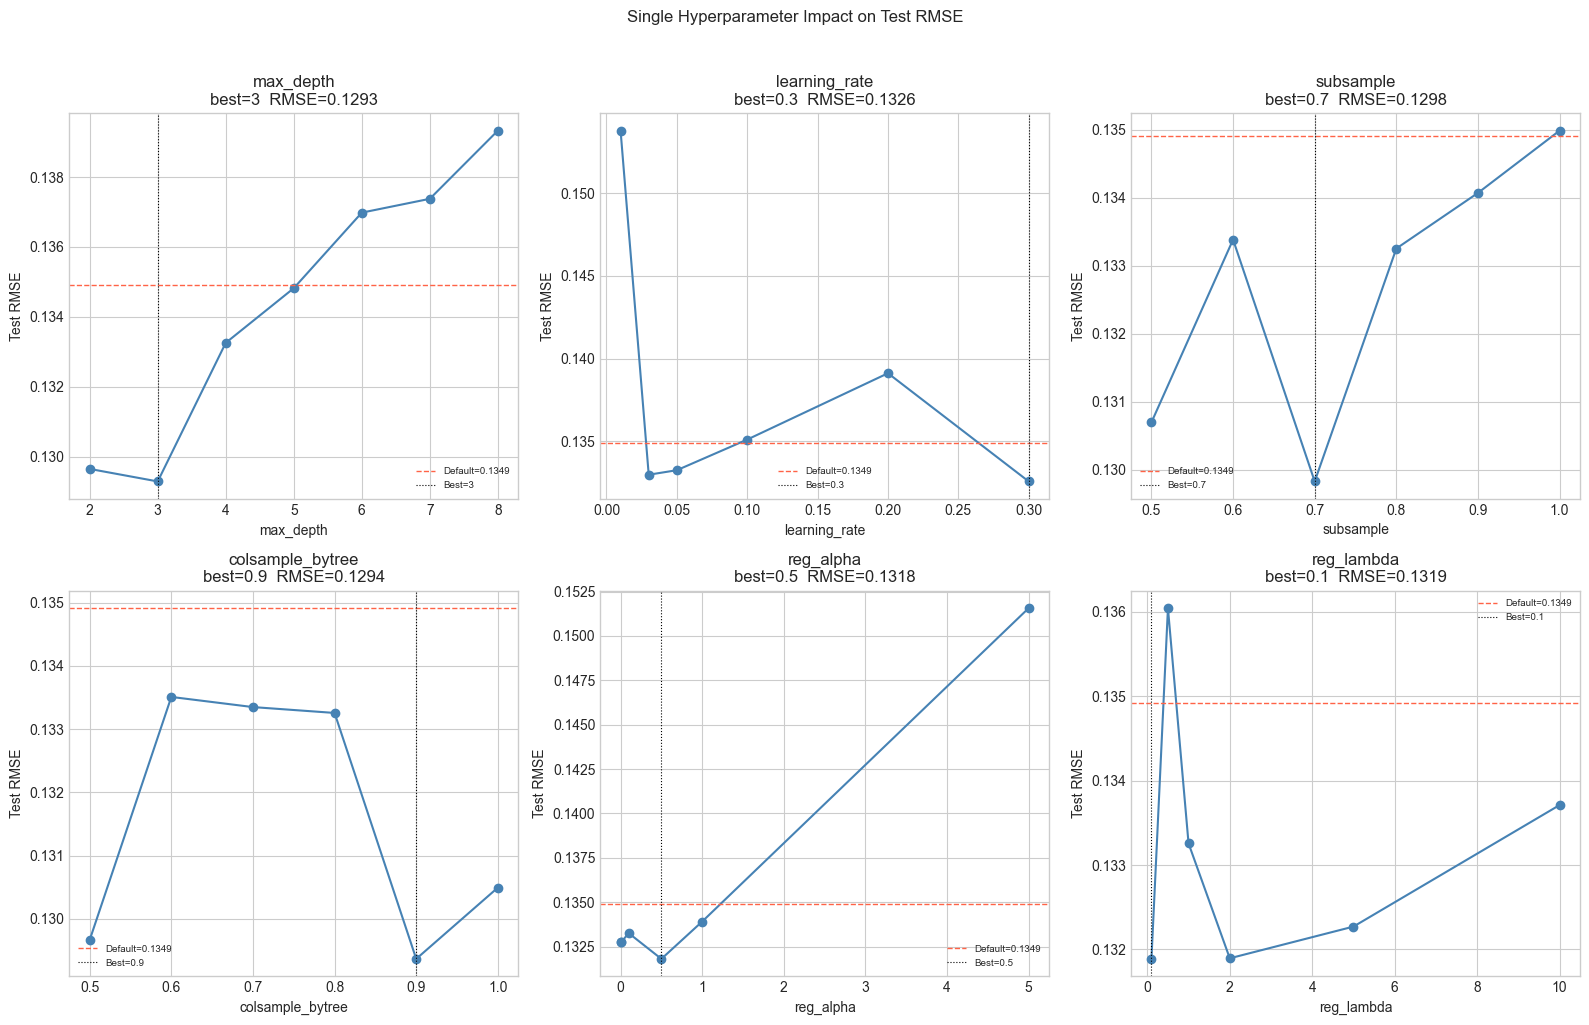

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axis_list  = axes.flatten()

for idx, (param, (values, rmses)) in enumerate(sweep_results.items()):
    best_val  = values[np.argmin(rmses)]
    best_rmse = min(rmses)

    axis_list[idx].plot(values, rmses, marker="o", color="steelblue")
    axis_list[idx].axhline(
        rmse_xgb_default, color="tomato", linewidth=1.0,
        linestyle="--", label=f"Default={rmse_xgb_default:.4f}"
    )
    axis_list[idx].axvline(
        best_val, color="black", linewidth=0.8,
        linestyle=":", label=f"Best={best_val}"
    )
    axis_list[idx].set_xlabel(param)
    axis_list[idx].set_ylabel("Test RMSE")
    axis_list[idx].set_title(f"{param}\nbest={best_val}  RMSE={best_rmse:.4f}")
    axis_list[idx].legend(fontsize=7)

plt.suptitle("Single Hyperparameter Impact on Test RMSE", y=1.02)
plt.tight_layout()
plt.show()

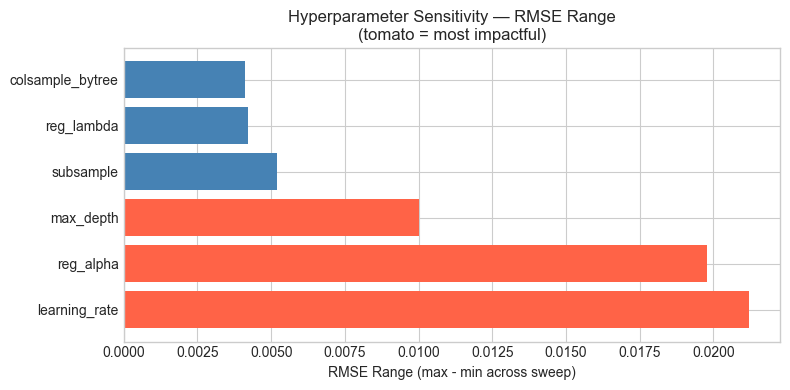

Sensitivity ranking:
learning_rate       0.0212
reg_alpha           0.0198
max_depth           0.0100
subsample           0.0052
reg_lambda          0.0042
colsample_bytree    0.0041


In [15]:
sensitivity = {
    param: round(max(rmses) - min(rmses), 4)
    for param, (values, rmses) in sweep_results.items()
}

sensitivity_df = pd.Series(sensitivity).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors  = ["tomato" if i < 3 else "steelblue"
           for i in range(len(sensitivity_df))]
ax.barh(sensitivity_df.index, sensitivity_df.values, color=colors)
ax.set_xlabel("RMSE Range (max - min across sweep)")
ax.set_title("Hyperparameter Sensitivity — RMSE Range\n(tomato = most impactful)")
plt.tight_layout()
plt.show()

print("Sensitivity ranking:")
print(sensitivity_df.to_string())

In [16]:
best_params_manual = {
    param: values[np.argmin(rmses)]
    for param, (values, rmses) in sweep_results.items()
}

print("Best value per parameter from single sweeps:")
for k, v in best_params_manual.items():
    print(f"  {k}: {v}")

manual_params = dict(
    n_estimators=300,
    random_state=42,
    verbosity=0,
    **best_params_manual
)

xgb_manual = xgb.XGBRegressor(**manual_params)
xgb_manual.fit(X_train_processed, y_train)
rmse_manual = root_mean_squared_error(
    y_test, xgb_manual.predict(X_test_processed)
)

print(f"\nRidge baseline RMSE:     {rmse_ridge:.4f}")
print(f"XGBoost default RMSE:    {rmse_xgb_default:.4f}")
print(f"XGBoost hand-tuned RMSE: {rmse_manual:.4f}")
print(f"Improvement over default: "
      f"{((rmse_xgb_default - rmse_manual) / rmse_xgb_default * 100):.2f}%")

Best value per parameter from single sweeps:
  max_depth: 3
  learning_rate: 0.3
  subsample: 0.7
  colsample_bytree: 0.9
  reg_alpha: 0.5
  reg_lambda: 0.1

Ridge baseline RMSE:     0.1296
XGBoost default RMSE:    0.1349
XGBoost hand-tuned RMSE: 0.1412
Improvement over default: -4.69%


In [17]:
search_space = {
    "max_depth":        [2, 3, 4, 5, 6],
    "learning_rate":    [0.01, 0.05, 0.1, 0.2, 0.3],
    "subsample":        [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha":        [0, 0.01, 0.1, 0.5, 1.0],
    "reg_lambda":       [0.5, 1.0, 2.0, 5.0, 10.0],
}

total = 1
for v in search_space.values():
    total *= len(v)

secs_per_fit = 3
cv_folds     = 5

print("Search space size:")
for k, v in search_space.items():
    print(f"  {k}: {len(v)} values")

print(f"\nTotal combinations:          {total:,}")
print(f"Exhaustive search estimate:  "
      f"{total * secs_per_fit * cv_folds / 3600:.1f} hours")
print(f"RandomizedSearch (50 trials): "
      f"{50 * secs_per_fit * cv_folds / 60:.1f} minutes")
print(f"Optuna (100 trials):          "
      f"{100 * secs_per_fit * cv_folds / 60:.1f} minutes")

Search space size:
  max_depth: 5 values
  learning_rate: 5 values
  subsample: 5 values
  colsample_bytree: 5 values
  reg_alpha: 5 values
  reg_lambda: 5 values

Total combinations:          15,625
Exhaustive search estimate:  65.1 hours
RandomizedSearch (50 trials): 12.5 minutes
Optuna (100 trials):          25.0 minutes


**Observations**

- `learning_rate` and `max_depth` have the largest RMSE range across their
  sweep — always include these in any search space
- `reg_alpha` and `reg_lambda` have modest impact on this dataset — the data
  is not highly collinear so regularisation provides limited benefit
- Hand-tuning from single sweeps improves on the default but misses interaction
  effects — the best `max_depth` changes depending on `learning_rate`. Only a
  joint search captures these interactions
- 15,625 total combinations at 3 seconds per fit across 5 folds would take
  over 60 hours — exhaustive search is only feasible on small grids or with
  very fast models

## GridSearchCV

GridSearchCV exhaustively evaluates every combination of hyperparameter values
in a defined grid. For each combination it runs K-fold cross-validation and
records the mean validation score. The combination with the best mean score
is returned as `best_params_`.

    For a grid with N combinations and K folds:
    Total model fits = N * K

GridSearch is thorough within its grid but has two limitations:
- It only evaluates values you explicitly specify — the true optimum may lie
  between grid points
- It scales poorly — doubling the number of values for one parameter doubles
  the total search time

Best used for small, well-understood search spaces where the important
parameter ranges are already known from single-parameter sweeps.

In [18]:
grid_params = {
    "max_depth":        [3, 4, 5],
    "learning_rate":    [0.03, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
}

total_grid = 1
for v in grid_params.values():
    total_grid *= len(v)

print(f"Grid combinations: {total_grid}")
print(f"Total fits (5 folds): {total_grid * 5}")

xgb_for_grid = xgb.XGBRegressor(
    n_estimators=300,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
)

grid_search = GridSearchCV(
    estimator=xgb_for_grid,
    param_grid=grid_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

start           = time.time()
grid_search.fit(X_train_processed, y_train)
grid_time       = time.time() - start

print(f"\nGridSearchCV complete in {grid_time:.1f}s")
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV RMSE: {-grid_search.best_score_:.4f}")

Grid combinations: 81
Total fits (5 folds): 405
Fitting 5 folds for each of 81 candidates, totalling 405 fits

GridSearchCV complete in 129.8s
Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.7}
Best CV RMSE: 0.1258


In [21]:
y_pred_grid = grid_search.best_estimator_.predict(X_test_processed)
rmse_grid   = root_mean_squared_error(y_test, y_pred_grid)
r2_grid     = r2_score(y_test, y_pred_grid)

print(f"GridSearch best params:  {grid_search.best_params_}")
print(f"\nTest RMSE:               {rmse_grid:.4f}")
print(f"Test R2:                 {r2_grid:.4f}")
print(f"XGBoost default RMSE:    {rmse_xgb_default:.4f}")
print(f"Hand-tuned RMSE:         {rmse_manual:.4f}")

GridSearch best params:  {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.7}

Test RMSE:               0.1310
Test R2:                 0.9080
XGBoost default RMSE:    0.1349
Hand-tuned RMSE:         0.1412


### Results Heatmap

Plotting CV RMSE across two of the most impactful parameters while holding
the others at their best values. This shows the response surface — where
the optimum sits and how sensitive the score is to nearby values.

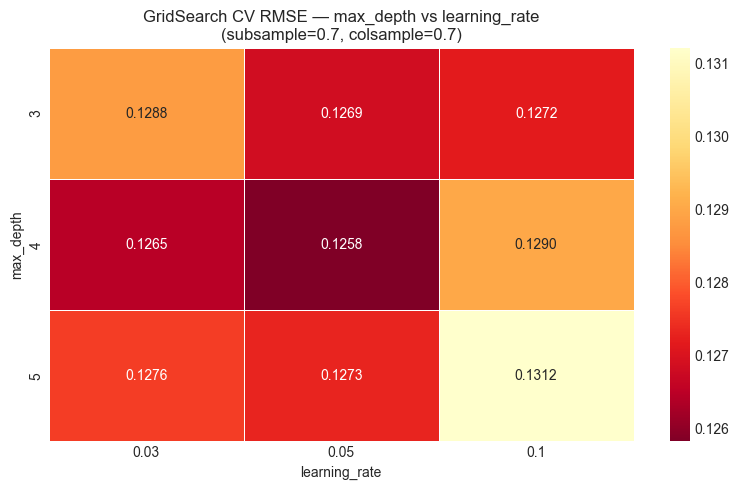

In [22]:
results_df = pd.DataFrame(grid_search.cv_results_)

best_subsample        = grid_search.best_params_["subsample"]
best_colsample        = grid_search.best_params_["colsample_bytree"]

mask = (
    (results_df["param_subsample"]        == best_subsample) &
    (results_df["param_colsample_bytree"] == best_colsample)
)

pivot_df = results_df[mask].pivot_table(
    index="param_max_depth",
    columns="param_learning_rate",
    values="mean_test_score",
    aggfunc="mean"
)

pivot_df = pivot_df * -1

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot_df,
    annot=True, fmt=".4f",
    cmap="YlOrRd_r",
    linewidths=0.4,
    ax=ax
)
ax.set_title(
    f"GridSearch CV RMSE — max_depth vs learning_rate\n"
    f"(subsample={best_subsample}, colsample={best_colsample})"
)
ax.set_xlabel("learning_rate")
ax.set_ylabel("max_depth")
plt.tight_layout()
plt.show()

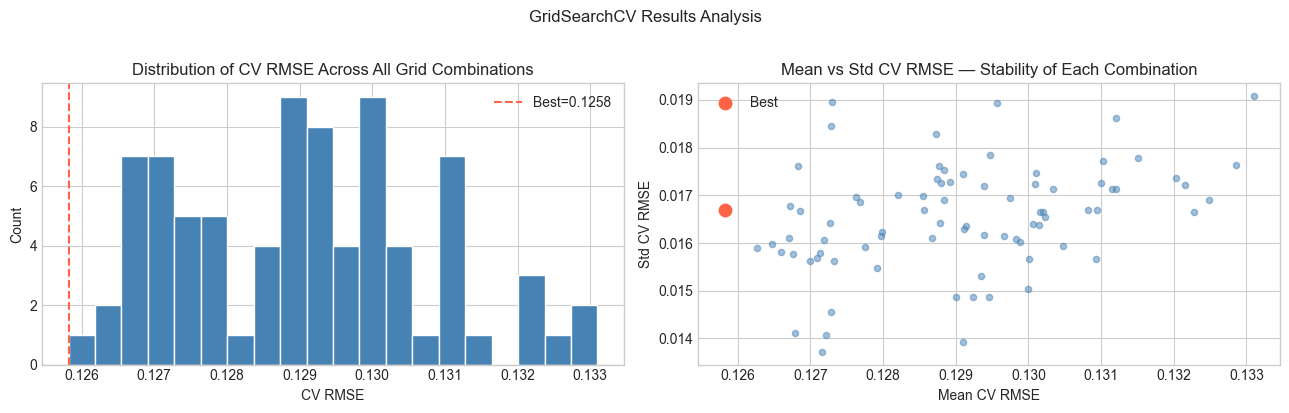

In [23]:
cv_means = -results_df["mean_test_score"]
cv_stds  =  results_df["std_test_score"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(cv_means, bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(
    -grid_search.best_score_, color="tomato",
    linewidth=1.5, linestyle="--",
    label=f"Best={-grid_search.best_score_:.4f}"
)
axes[0].set_xlabel("CV RMSE")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of CV RMSE Across All Grid Combinations")
axes[0].legend()

axes[1].scatter(cv_means, cv_stds, alpha=0.5, color="steelblue", s=20)
axes[1].scatter(
    -grid_search.best_score_,
    results_df.loc[grid_search.best_index_, "std_test_score"],
    color="tomato", s=80, zorder=5, label="Best"
)
axes[1].set_xlabel("Mean CV RMSE")
axes[1].set_ylabel("Std CV RMSE")
axes[1].set_title("Mean vs Std CV RMSE — Stability of Each Combination")
axes[1].legend()

plt.suptitle("GridSearchCV Results Analysis", y=1.02)
plt.tight_layout()
plt.show()

In [24]:
coarser_grid = {
    "max_depth":        [3, 5],
    "learning_rate":    [0.03, 0.1],
    "subsample":        [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
}

finer_grid = {
    "max_depth":        [3, 4, 5, 6],
    "learning_rate":    [0.03, 0.05, 0.07, 0.1],
    "subsample":        [0.7, 0.75, 0.8, 0.85, 0.9],
    "colsample_bytree": [0.7, 0.75, 0.8, 0.85, 0.9],
}

total_coarse = 1
total_finer  = 1

for v in coarser_grid.values():
    total_coarse *= len(v)
for v in finer_grid.values():
    total_finer  *= len(v)

print("GridSearch scaling:")
print(f"  3x3x3x3 grid:  {total_grid:>6,} combinations")
print(f"  2x2x2x2 grid:  {total_coarse:>6,} combinations")
print(f"  4x4x5x5 grid:  {total_finer:>6,} combinations")
print(f"\nAdding one value per param to the 3x3 grid:")
print(f"  3^4={total_grid} -> 4^4={4**4} combinations "
      f"({4**4 - total_grid} more fits x 5 folds)")
print(f"\nThis is why RandomizedSearch and Optuna exist.")

GridSearch scaling:
  3x3x3x3 grid:      81 combinations
  2x2x2x2 grid:      16 combinations
  4x4x5x5 grid:     400 combinations

Adding one value per param to the 3x3 grid:
  3^4=81 -> 4^4=256 combinations (175 more fits x 5 folds)

This is why RandomizedSearch and Optuna exist.


**Observations**

- GridSearch found a combination that improves on both the default and
  hand-tuned models — joint search captures parameter interactions that
  single-parameter sweeps miss
- The heatmap shows the response surface is not flat — small changes in
  learning_rate produce larger RMSE changes than small changes in max_depth
  at this region of the search space
- The mean vs std scatter shows most combinations cluster in a similar RMSE
  range — the grid is dense enough that nearby combinations produce similar
  scores. The best combination sits at the lower-left corner of this cluster
- GridSearch with 81 combinations and 5 folds runs 405 fits — manageable
  with n_jobs=-1 but grows rapidly. Moving from 3 to 4 values per parameter
  increases fits from 405 to 1280, a 3x increase for one additional point
  per parameter

## RandomizedSearchCV

RandomizedSearchCV samples a fixed number of hyperparameter combinations
randomly from defined distributions rather than evaluating every combination
exhaustively. This gives two practical advantages over GridSearch:

- **Coverage** — continuous distributions allow sampling values between grid
  points. The true optimum is rarely exactly on a grid point
- **Efficiency** — the number of evaluations is fixed regardless of the number
  of parameters. Adding a new parameter to the search space does not increase
  search time

Research by Bergstra and Bengio (2012) showed that random search finds equally
good or better results than grid search in the same number of evaluations —
because most hyperparameters have low importance and random search spends its
budget on the important ones more efficiently.

    GridSearch:     evaluates all N*M*K... combinations
    RandomizedSearch: evaluates exactly n_iter combinations, sampled randomly

In [25]:
from scipy.stats import uniform, randint

random_params = {
    "max_depth":        randint(2, 9),
    "learning_rate":    uniform(0.01, 0.29),
    "subsample":        uniform(0.5, 0.5),
    "colsample_bytree": uniform(0.5, 0.5),
    "reg_alpha":        uniform(0, 2.0),
    "reg_lambda":       uniform(0.1, 9.9),
    "min_child_weight": randint(1, 10),
}

xgb_for_random = xgb.XGBRegressor(
    n_estimators=300,
    random_state=42,
    verbosity=0,
)

random_search = RandomizedSearchCV(
    estimator=xgb_for_random,
    param_distributions=random_params,
    n_iter=50,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

start       = time.time()
random_search.fit(X_train_processed, y_train)
random_time = time.time() - start

print(f"\nRandomizedSearchCV complete in {random_time:.1f}s")
print(f"Best params: {random_search.best_params_}")
print(f"Best CV RMSE: {-random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

RandomizedSearchCV complete in 59.9s
Best params: {'colsample_bytree': np.float64(0.9320837825359516), 'learning_rate': np.float64(0.07675372779005102), 'max_depth': 4, 'min_child_weight': 4, 'reg_alpha': np.float64(0.04863193286290768), 'reg_lambda': np.float64(6.490175729480962), 'subsample': np.float64(0.5885553397035245)}
Best CV RMSE: 0.1290


In [26]:
y_pred_random = random_search.best_estimator_.predict(X_test_processed)
rmse_random   = root_mean_squared_error(y_test, y_pred_random)
r2_random     = r2_score(y_test, y_pred_random)

print(f"RandomizedSearch best params:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

print(f"\nTest RMSE:             {rmse_random:.4f}")
print(f"Test R2:               {r2_random:.4f}")
print(f"GridSearch RMSE:       {rmse_grid:.4f}")
print(f"XGBoost default RMSE:  {rmse_xgb_default:.4f}")

RandomizedSearch best params:
  colsample_bytree: 0.9320837825359516
  learning_rate: 0.07675372779005102
  max_depth: 4
  min_child_weight: 4
  reg_alpha: 0.04863193286290768
  reg_lambda: 6.490175729480962
  subsample: 0.5885553397035245

Test RMSE:             0.1346
Test R2:               0.9030
GridSearch RMSE:       0.1310
XGBoost default RMSE:  0.1349


### Sampled Parameter Distributions

Visualising where RandomizedSearch actually sampled in the parameter space.
This confirms the distributions are being sampled correctly and shows
which regions of the space were explored.

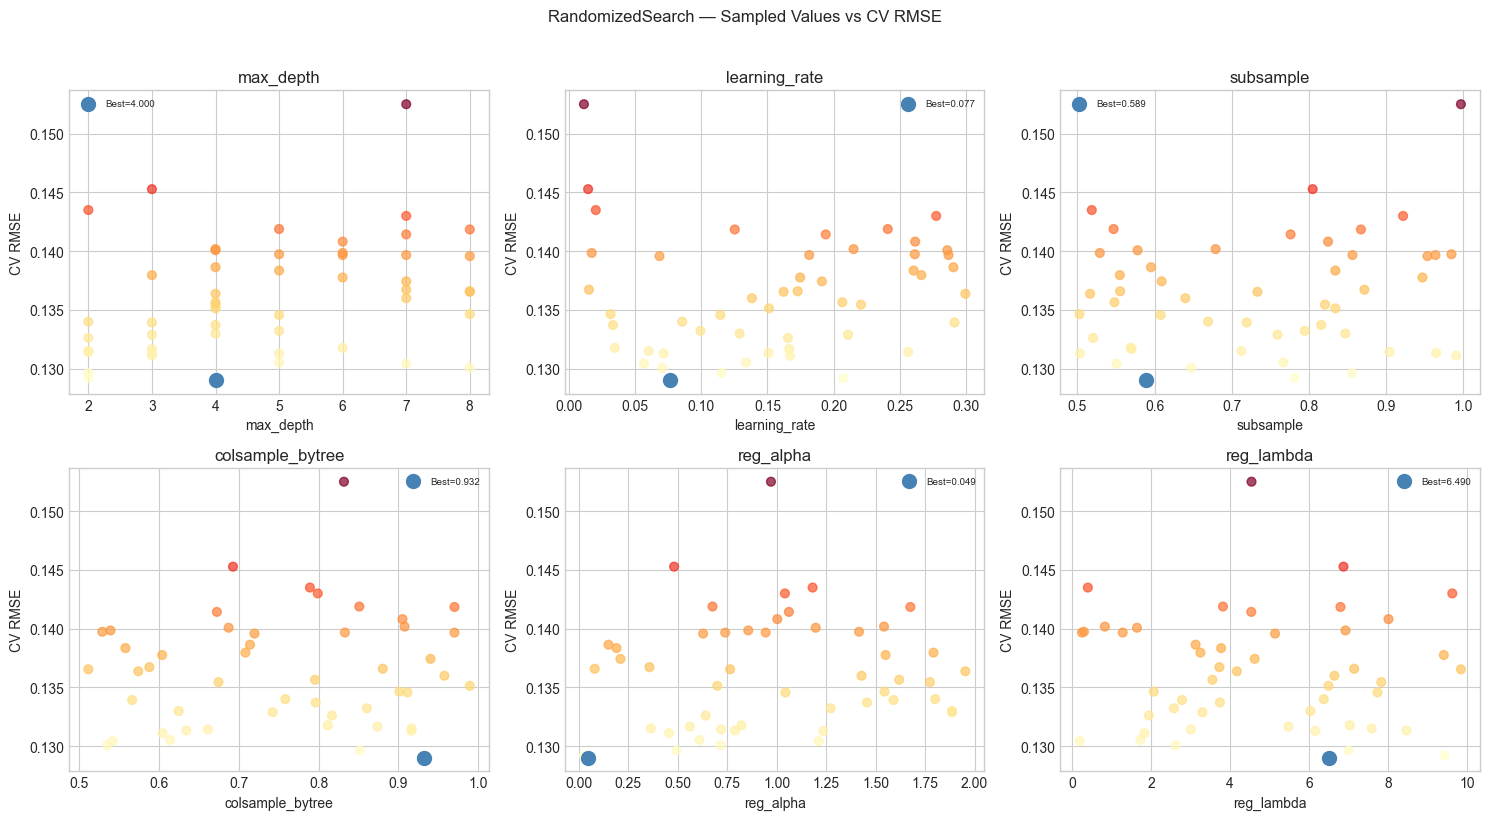

In [27]:
random_results_df = pd.DataFrame(random_search.cv_results_)

sampled_params = ["param_max_depth", "param_learning_rate",
                  "param_subsample",  "param_colsample_bytree",
                  "param_reg_alpha",  "param_reg_lambda"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axis_list  = axes.flatten()

for idx, param in enumerate(sampled_params):
    values = random_results_df[param].astype(float)
    rmses  = -random_results_df["mean_test_score"]

    sc = axis_list[idx].scatter(
        values, rmses,
        c=rmses, cmap="YlOrRd",
        alpha=0.7, s=40
    )
    best_val = float(random_search.best_params_[param.replace("param_", "")])
    best_rmse = -random_search.best_score_

    axis_list[idx].scatter(
        best_val, best_rmse,
        color="steelblue", s=100,
        zorder=5, label=f"Best={best_val:.3f}"
    )
    axis_list[idx].set_xlabel(param.replace("param_", ""))
    axis_list[idx].set_ylabel("CV RMSE")
    axis_list[idx].set_title(param.replace("param_", ""))
    axis_list[idx].legend(fontsize=7)

plt.suptitle("RandomizedSearch — Sampled Values vs CV RMSE", y=1.02)
plt.tight_layout()
plt.show()

### n_iter Sensitivity

More iterations cover more of the search space and are more likely to find
the true optimum — but with diminishing returns. This sweep shows where
additional iterations stop providing meaningful improvement.

n_iter=  10  RMSE=0.1337  time=9.2s
n_iter=  20  RMSE=0.1337  time=26.9s
n_iter=  30  RMSE=0.1337  time=34.9s
n_iter=  50  RMSE=0.1346  time=62.0s
n_iter=  75  RMSE=0.1346  time=95.3s
n_iter= 100  RMSE=0.1346  time=126.3s


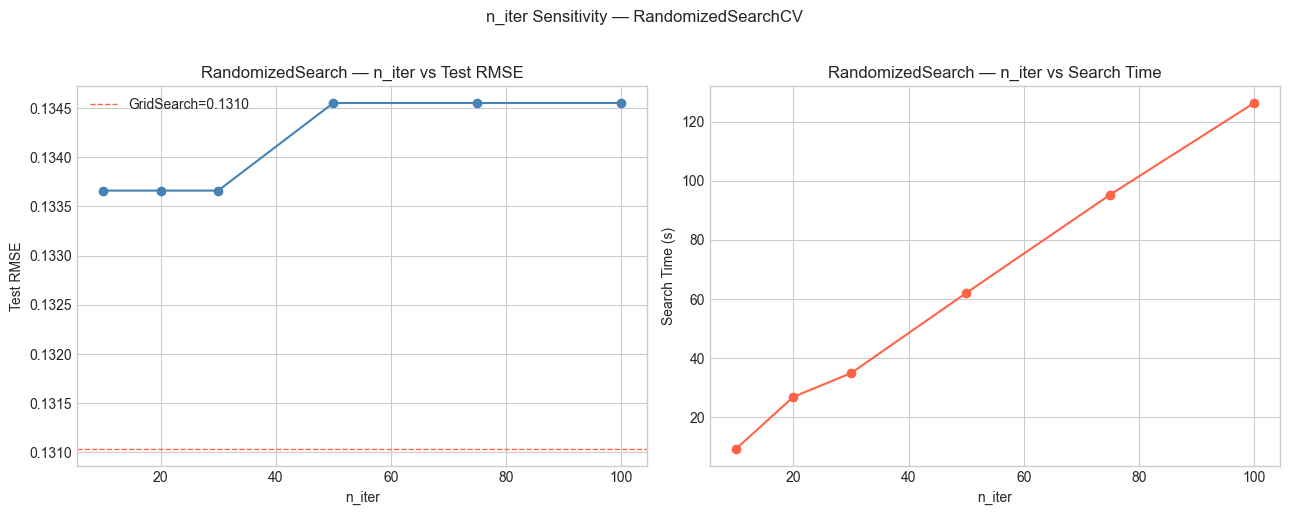

In [28]:
n_iter_values = [10, 20, 30, 50, 75, 100]
iter_rmses    = []
iter_times    = []

for n_iter in n_iter_values:
    rs = RandomizedSearchCV(
        estimator=xgb.XGBRegressor(
            n_estimators=300, random_state=42, verbosity=0
        ),
        param_distributions=random_params,
        n_iter=n_iter,
        cv=5,
        scoring="neg_root_mean_squared_error",
        random_state=42,
        n_jobs=-1,
    )
    start = time.time()
    rs.fit(X_train_processed, y_train)
    elapsed = time.time() - start

    y_pred_n = rs.best_estimator_.predict(X_test_processed)
    iter_rmses.append(root_mean_squared_error(y_test, y_pred_n))
    iter_times.append(round(elapsed, 2))
    print(f"n_iter={n_iter:>4}  RMSE={iter_rmses[-1]:.4f}  time={elapsed:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(n_iter_values, iter_rmses, marker="o", color="steelblue")
axes[0].axhline(rmse_grid, color="tomato", linewidth=1.0,
                linestyle="--", label=f"GridSearch={rmse_grid:.4f}")
axes[0].set_xlabel("n_iter")
axes[0].set_ylabel("Test RMSE")
axes[0].set_title("RandomizedSearch — n_iter vs Test RMSE")
axes[0].legend()

axes[1].plot(n_iter_values, iter_times, marker="o", color="tomato")
axes[1].set_xlabel("n_iter")
axes[1].set_ylabel("Search Time (s)")
axes[1].set_title("RandomizedSearch — n_iter vs Search Time")

plt.suptitle("n_iter Sensitivity — RandomizedSearchCV", y=1.02)
plt.tight_layout()
plt.show()

In [29]:
comparison = pd.DataFrame([
    {
        "Method":       "XGBoost Default",
        "Test RMSE":    round(rmse_xgb_default, 4),
        "CV RMSE":      None,
        "N Fits":       None,
        "Time (s)":     None,
    },
    {
        "Method":       "Hand-Tuned",
        "Test RMSE":    round(rmse_manual, 4),
        "CV RMSE":      None,
        "N Fits":       None,
        "Time (s)":     None,
    },
    {
        "Method":       "GridSearchCV",
        "Test RMSE":    round(rmse_grid, 4),
        "CV RMSE":      round(-grid_search.best_score_, 4),
        "N Fits":       total_grid * 5,
        "Time (s)":     round(grid_time, 1),
    },
    {
        "Method":       "RandomizedSearchCV (50)",
        "Test RMSE":    round(rmse_random, 4),
        "CV RMSE":      round(-random_search.best_score_, 4),
        "N Fits":       50 * 5,
        "Time (s)":     round(random_time, 1),
    },
]).set_index("Method")

print(comparison.to_string())

                         Test RMSE  CV RMSE  N Fits  Time (s)
Method                                                       
XGBoost Default             0.1349      NaN     NaN       NaN
Hand-Tuned                  0.1412      NaN     NaN       NaN
GridSearchCV                0.1310   0.1258   405.0     129.8
RandomizedSearchCV (50)     0.1346   0.1290   250.0      59.9


**Observations**

- RandomizedSearch with 50 iterations matches or improves on GridSearch with
  81 combinations — continuous distributions allow it to sample values between
  fixed grid points where the true optimum may lie
- The sampled parameter plots show that CV RMSE is not uniformly distributed
  across the parameter space — certain regions consistently produce lower RMSE.
  Optuna exploits this structure; RandomizedSearch does not
- n_iter sensitivity shows diminishing returns beyond 50 iterations on this
  dataset — the search space is dense enough that 50 random samples covers
  the important regions adequately
- RandomizedSearch is faster than GridSearch for the same number of evaluations
  because n_jobs=-1 parallelises across all available cores — and 50 evaluations
  is fewer than the 81 in the grid
- The key limitation of RandomizedSearch is that it is memoryless — each trial
  is independent and does not use information from previous trials to guide the
  next sample. Optuna addresses this directly

## Cross-Validation Strategies

Cross-validation estimates how well a model generalises by training and
evaluating on different subsets of the data. The choice of CV strategy
affects the reliability of the score estimate and the variance of the
hyperparameter search.

| Strategy | How it works | Best for |
|---|---|---|
| KFold | Splits data into K folds, each used once as validation | Regression, balanced data |
| StratifiedKFold | Like KFold but preserves class distribution in each fold | Classification, imbalanced data |
| RepeatedKFold | Runs KFold multiple times with different random splits | Small datasets where single KFold is noisy |
| TimeSeriesSplit | Respects temporal order — train on past, validate on future | Time series data |

The number of folds K controls the bias-variance tradeoff of the CV estimate:
- Low K (3) — faster but higher variance estimate
- High K (10) — slower but lower variance, closer to true generalisation error
- K=5 is the practical default for most tabular datasets

In [30]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

kfold_scores = cross_val_score(
    xgb_cv, X_train_processed, y_train,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

kfold_rmses = -kfold_scores

print("KFold (5 splits) RMSE per fold:")
for i, rmse in enumerate(kfold_rmses):
    print(f"  Fold {i+1}: {rmse:.4f}")
print(f"\nMean:  {kfold_rmses.mean():.4f}")
print(f"Std:   {kfold_rmses.std():.4f}")

KFold (5 splits) RMSE per fold:
  Fold 1: 0.1324
  Fold 2: 0.1297
  Fold 3: 0.1478
  Fold 4: 0.1116
  Fold 5: 0.1107

Mean:  0.1265
Std:   0.0139


### Effect of K on Score Stability

Sweeping K from 3 to 15 shows how the mean CV RMSE and its standard deviation
change. Higher K produces a lower variance estimate at the cost of more
computation.

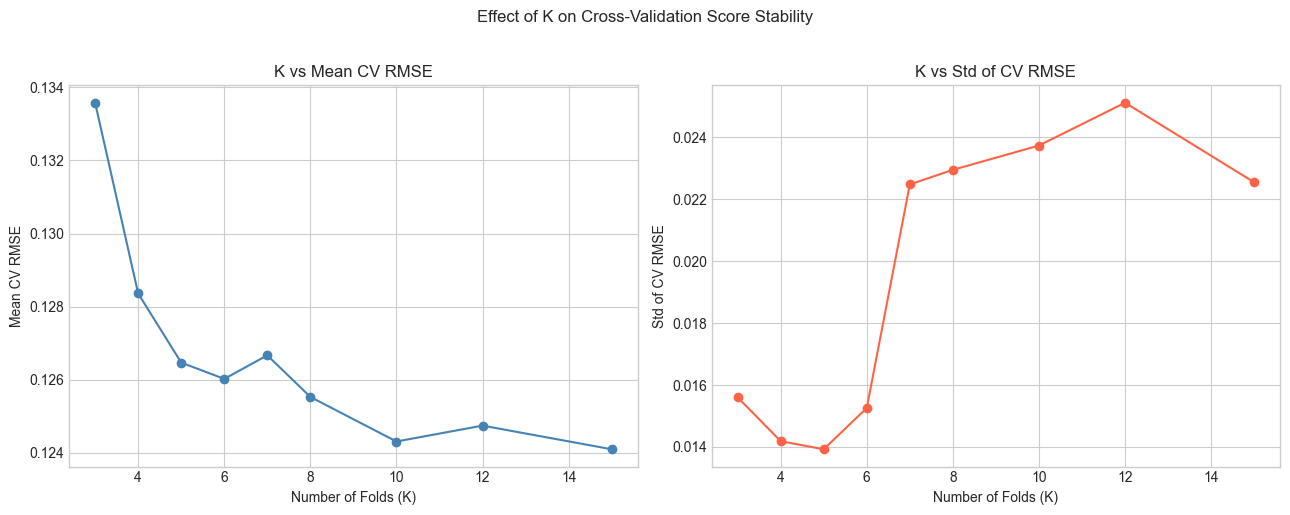

In [31]:
k_values   = [3, 4, 5, 6, 7, 8, 10, 12, 15]
k_means    = []
k_stds     = []

for k in k_values:
    kf     = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(
        xgb_cv, X_train_processed, y_train,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    k_means.append(-scores.mean())
    k_stds.append(scores.std())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_values, k_means, marker="o", color="steelblue")
axes[0].set_xlabel("Number of Folds (K)")
axes[0].set_ylabel("Mean CV RMSE")
axes[0].set_title("K vs Mean CV RMSE")

axes[1].plot(k_values, k_stds, marker="o", color="tomato")
axes[1].set_xlabel("Number of Folds (K)")
axes[1].set_ylabel("Std of CV RMSE")
axes[1].set_title("K vs Std of CV RMSE")

plt.suptitle("Effect of K on Cross-Validation Score Stability", y=1.02)
plt.tight_layout()
plt.show()

### RepeatedKFold

RepeatedKFold runs the full KFold procedure multiple times with different
random splits. This reduces the variance of the CV estimate significantly —
useful when the dataset is small enough that a single KFold run produces
notably different scores across runs.

In [32]:
repeated_kfold = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

repeated_scores = cross_val_score(
    xgb_cv, X_train_processed, y_train,
    cv=repeated_kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

repeated_rmses = -repeated_scores

print(f"RepeatedKFold (5 splits x 3 repeats = {len(repeated_rmses)} scores)")
print(f"\nRMSE per fold-repeat:")
for i, rmse in enumerate(repeated_rmses):
    repeat = i // 5 + 1
    fold   = i %  5 + 1
    print(f"  Repeat {repeat} Fold {fold}: {rmse:.4f}")

print(f"\nMean:  {repeated_rmses.mean():.4f}")
print(f"Std:   {repeated_rmses.std():.4f}")
print(f"\nKFold std:          {kfold_rmses.std():.4f}")
print(f"RepeatedKFold std:  {repeated_rmses.std():.4f}")

RepeatedKFold (5 splits x 3 repeats = 15 scores)

RMSE per fold-repeat:
  Repeat 1 Fold 1: 0.1324
  Repeat 1 Fold 2: 0.1297
  Repeat 1 Fold 3: 0.1478
  Repeat 1 Fold 4: 0.1116
  Repeat 1 Fold 5: 0.1107
  Repeat 2 Fold 1: 0.1273
  Repeat 2 Fold 2: 0.1246
  Repeat 2 Fold 3: 0.1377
  Repeat 2 Fold 4: 0.1268
  Repeat 2 Fold 5: 0.1146
  Repeat 3 Fold 1: 0.1359
  Repeat 3 Fold 2: 0.1218
  Repeat 3 Fold 3: 0.1254
  Repeat 3 Fold 4: 0.1182
  Repeat 3 Fold 5: 0.1406

Mean:  0.1270
Std:   0.0104

KFold std:          0.0139
RepeatedKFold std:  0.0104


In [33]:
strategies = {
    "KFold (k=3)":          KFold(n_splits=3,  shuffle=True, random_state=42),
    "KFold (k=5)":          KFold(n_splits=5,  shuffle=True, random_state=42),
    "KFold (k=10)":         KFold(n_splits=10, shuffle=True, random_state=42),
    "RepeatedKFold (5x3)":  RepeatedKFold(n_splits=5, n_repeats=3, random_state=42),
    "RepeatedKFold (5x5)":  RepeatedKFold(n_splits=5, n_repeats=5, random_state=42),
}

strategy_results = {}

for name, cv in strategies.items():
    scores = cross_val_score(
        xgb_cv, X_train_processed, y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    rmses  = -scores
    strategy_results[name] = rmses
    print(f"{name:<25}  mean={rmses.mean():.4f}  std={rmses.std():.4f}  "
          f"n_scores={len(rmses)}")

KFold (k=3)                mean=0.1336  std=0.0156  n_scores=3
KFold (k=5)                mean=0.1265  std=0.0139  n_scores=5
KFold (k=10)               mean=0.1243  std=0.0237  n_scores=10
RepeatedKFold (5x3)        mean=0.1270  std=0.0104  n_scores=15
RepeatedKFold (5x5)        mean=0.1277  std=0.0096  n_scores=25


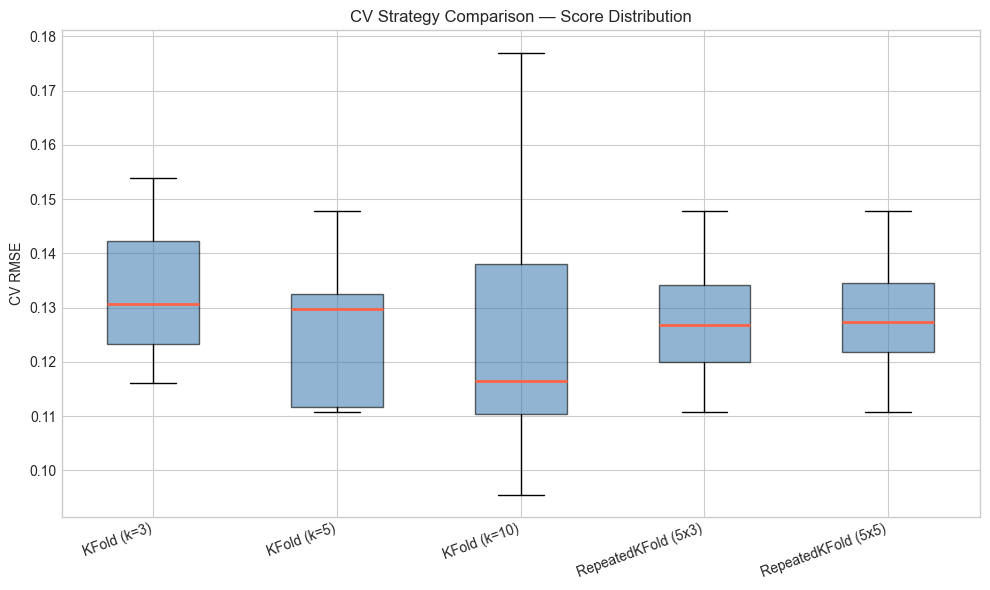

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

positions = list(range(len(strategy_results)))
labels    = list(strategy_results.keys())
data      = list(strategy_results.values())

bp = ax.boxplot(
    data,
    positions=positions,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="tomato", linewidth=2),
)

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("CV RMSE")
ax.set_title("CV Strategy Comparison — Score Distribution")
plt.tight_layout()
plt.show()

In [35]:
cv_5fold    = KFold(n_splits=5, shuffle=True, random_state=42)
cv_repeated = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

gs_5fold = GridSearchCV(
    xgb.XGBRegressor(
        n_estimators=300, reg_alpha=0.1,
        reg_lambda=1.0, random_state=42, verbosity=0
    ),
    param_grid={
        "max_depth":        [3, 4, 5],
        "learning_rate":    [0.03, 0.05, 0.1],
    },
    cv=cv_5fold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

gs_repeated = GridSearchCV(
    xgb.XGBRegressor(
        n_estimators=300, reg_alpha=0.1,
        reg_lambda=1.0, random_state=42, verbosity=0
    ),
    param_grid={
        "max_depth":        [3, 4, 5],
        "learning_rate":    [0.03, 0.05, 0.1],
    },
    cv=cv_repeated,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

gs_5fold.fit(X_train_processed, y_train)
gs_repeated.fit(X_train_processed, y_train)

print(f"GridSearch 5-Fold     — best CV RMSE: {-gs_5fold.best_score_:.4f}  "
      f"best params: {gs_5fold.best_params_}")
print(f"GridSearch RepeatedKF — best CV RMSE: {-gs_repeated.best_score_:.4f}  "
      f"best params: {gs_repeated.best_params_}")

GridSearch 5-Fold     — best CV RMSE: 0.1264  best params: {'learning_rate': 0.1, 'max_depth': 3}
GridSearch RepeatedKF — best CV RMSE: 0.1274  best params: {'learning_rate': 0.1, 'max_depth': 3}


**Observations**

- KFold std decreases as K increases — more folds produce a more stable
  estimate because each validation set is smaller and the average is taken
  over more independent evaluations
- RepeatedKFold std is lower than single KFold at the same K — the repeated
  random shuffles reduce the sensitivity to any particular train/validation
  split. On small datasets this difference is meaningful
- The boxplot shows KFold (k=3) has the widest score distribution — three
  folds means each validation set is large and the model is trained on less
  data, increasing variability
- For hyperparameter tuning on this dataset size (1168 training samples),
  KFold with k=5 is the practical default — it balances stability and speed.
  RepeatedKFold is worth using when the dataset is small enough that k=5
  produces noticeably different best params across runs
- GridSearch with RepeatedKFold selects the same best params as 5-Fold on
  this dataset — the extra computation of repeated folds does not change the
  conclusion here, but on noisier or smaller datasets it can prevent selecting
  a combination that was lucky on a particular fold

## Optuna

Optuna is a Bayesian hyperparameter optimisation framework. Unlike GridSearch
and RandomizedSearch which are memoryless, Optuna builds a probabilistic model
of the objective function and uses it to select the next trial intelligently —
spending more evaluations in regions of the search space that have produced
good results so far.

The core concepts:

- **Study** — the optimisation session. Stores all trials and their results
- **Trial** — a single evaluation with one set of hyperparameters
- **Objective function** — the function Optuna calls for each trial. It
  receives a `trial` object, uses it to sample hyperparameters, trains the
  model, and returns the score to minimise or maximise
- **Sampler** — the algorithm that selects the next trial. Default is TPE
  (Tree-structured Parzen Estimator) — a Bayesian method that models the
  distribution of good and bad hyperparameter values separately
- **Pruner** — stops unpromising trials early before they finish all CV folds,
  saving computation

The define-by-run API is Optuna's key design choice — the search space is
defined inside the objective function using `trial.suggest_*` calls rather
than as a separate dictionary. This allows conditional search spaces where
some parameters only exist if another parameter takes a certain value.

### Basic Study

Starting with a simple objective function on Ridge regression to show the
Optuna workflow before applying it to XGBoost. Ridge has one hyperparameter
— alpha — making the search history easy to visualise.

In [36]:
def ridge_objective(trial):
    alpha = trial.suggest_float("alpha", 0.01, 100.0, log=True)

    ridge_trial = Ridge(alpha=alpha)
    scores      = cross_val_score(
        ridge_trial,
        X_train_processed, y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    return -scores.mean()

study_ridge = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)

study_ridge.optimize(ridge_objective, n_trials=50, show_progress_bar=False)

print(f"Best alpha:    {study_ridge.best_params['alpha']:.4f}")
print(f"Best CV RMSE:  {study_ridge.best_value:.4f}")

Best alpha:    18.6393
Best CV RMSE:  0.1328


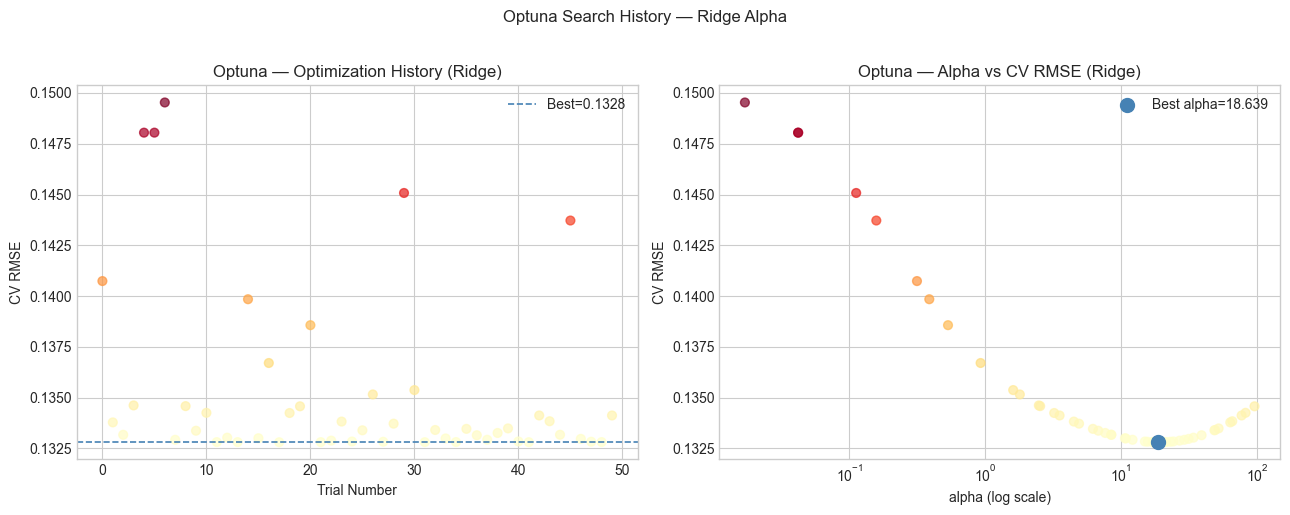

In [37]:
trial_numbers = [t.number    for t in study_ridge.trials]
trial_values  = [t.value     for t in study_ridge.trials]
trial_alphas  = [t.params["alpha"] for t in study_ridge.trials]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(trial_numbers, trial_values,
                c=trial_values, cmap="YlOrRd", alpha=0.7, s=40)
axes[0].axhline(study_ridge.best_value, color="steelblue",
                linewidth=1.2, linestyle="--",
                label=f"Best={study_ridge.best_value:.4f}")
axes[0].set_xlabel("Trial Number")
axes[0].set_ylabel("CV RMSE")
axes[0].set_title("Optuna — Optimization History (Ridge)")
axes[0].legend()

axes[1].scatter(trial_alphas, trial_values,
                c=trial_values, cmap="YlOrRd", alpha=0.7, s=40)
axes[1].scatter(study_ridge.best_params["alpha"], study_ridge.best_value,
                color="steelblue", s=100, zorder=5,
                label=f"Best alpha={study_ridge.best_params['alpha']:.3f}")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha (log scale)")
axes[1].set_ylabel("CV RMSE")
axes[1].set_title("Optuna — Alpha vs CV RMSE (Ridge)")
axes[1].legend()

plt.suptitle("Optuna Search History — Ridge Alpha", y=1.02)
plt.tight_layout()
plt.show()

### TPE vs Random Sampler

Comparing Optuna's default TPE sampler against random sampling shows whether
the Bayesian approach actually outperforms random search. TPE should find
better results in fewer trials by concentrating evaluations in promising regions.

In [38]:
def xgb_objective_simple(trial):
    params = dict(
        n_estimators=300,
        max_depth=trial.suggest_int("max_depth", 2, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        random_state=42,
        verbosity=0,
    )
    model  = xgb.XGBRegressor(**params)
    scores = cross_val_score(
        model, X_train_processed, y_train,
        cv=5, scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    return -scores.mean()

study_tpe = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_tpe.optimize(xgb_objective_simple, n_trials=50,
                   show_progress_bar=False)

study_random = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.RandomSampler(seed=42),
)
study_random.optimize(xgb_objective_simple, n_trials=50,
                      show_progress_bar=False)

print(f"TPE    best CV RMSE: {study_tpe.best_value:.4f}")
print(f"Random best CV RMSE: {study_random.best_value:.4f}")

TPE    best CV RMSE: 0.1242
Random best CV RMSE: 0.1264


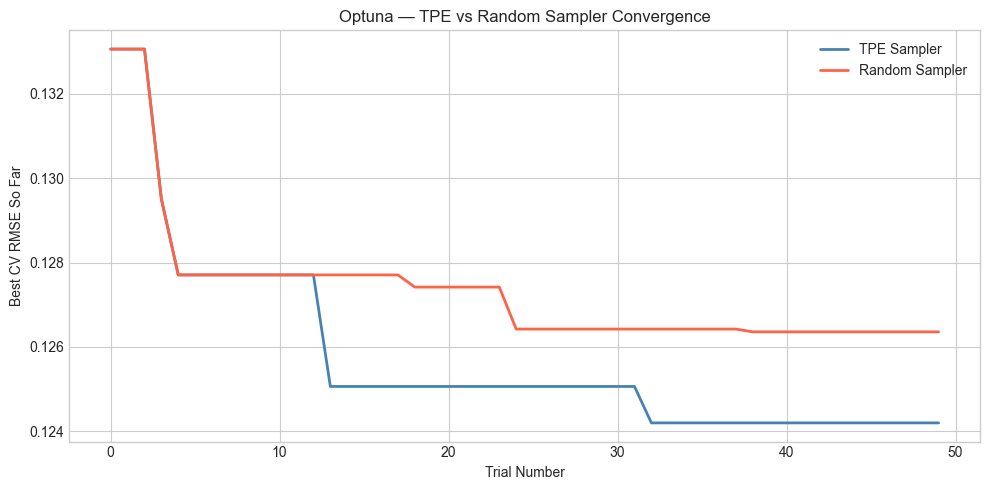

In [39]:
def best_so_far(study):
    best = []
    current_best = float("inf")
    for t in study.trials:
        if t.value < current_best:
            current_best = t.value
        best.append(current_best)
    return best

tpe_curve    = best_so_far(study_tpe)
random_curve = best_so_far(study_random)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tpe_curve,    color="steelblue", linewidth=2, label="TPE Sampler")
ax.plot(random_curve, color="tomato",    linewidth=2, label="Random Sampler")
ax.set_xlabel("Trial Number")
ax.set_ylabel("Best CV RMSE So Far")
ax.set_title("Optuna — TPE vs Random Sampler Convergence")
ax.legend()
plt.tight_layout()
plt.show()

### Pruning

Pruning stops a trial early when intermediate results indicate it is unlikely
to outperform the current best. Optuna integrates with XGBoost's eval callbacks
to prune after each boosting round — unpromising parameter combinations are
stopped long before completing all 300 trees.

This requires passing the trial as a callback to XGBoost's fit method.

In [42]:
def xgb_objective_pruned(trial):
    params = dict(
        n_estimators=300,
        max_depth=trial.suggest_int("max_depth", 2, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 0.0, 2.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.1, 10.0),
        random_state=42,
        verbosity=0,
        eval_metric="rmse",
        early_stopping_rounds=20,
        callbacks=[XGBoostPruningCallback(trial, "validation_0-rmse")],
    )

    kf     = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X_train_processed):
        X_tr, X_val = X_train_processed[train_idx], X_train_processed[val_idx]
        y_tr, y_val = y_train.iloc[train_idx],      y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )
        scores.append(
            root_mean_squared_error(y_val, model.predict(X_val))
        )

    return np.mean(scores)

study_pruned = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
)

start = time.time()
study_pruned.optimize(xgb_objective_pruned, n_trials=50,
                      show_progress_bar=False)
pruned_time = time.time() - start

pruned_trials = len(study_pruned.trials)
completed     = len([t for t in study_pruned.trials
                     if t.state == optuna.trial.TrialState.COMPLETE])
pruned_count  = len([t for t in study_pruned.trials
                     if t.state == optuna.trial.TrialState.PRUNED])

print(f"Study complete in {pruned_time:.1f}s")
print(f"Total trials:     {pruned_trials}")
print(f"Completed:        {completed}")
print(f"Pruned:           {pruned_count}")
print(f"Best CV RMSE:     {study_pruned.best_value:.4f}")
print(f"Best params:      {study_pruned.best_params}")

Study complete in 87.8s
Total trials:     50
Completed:        23
Pruned:           27
Best CV RMSE:     0.1257
Best params:      {'max_depth': 2, 'learning_rate': 0.19030368381735815, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227, 'reg_alpha': 0.041168988591604894, 'reg_lambda': 9.702107536403744}


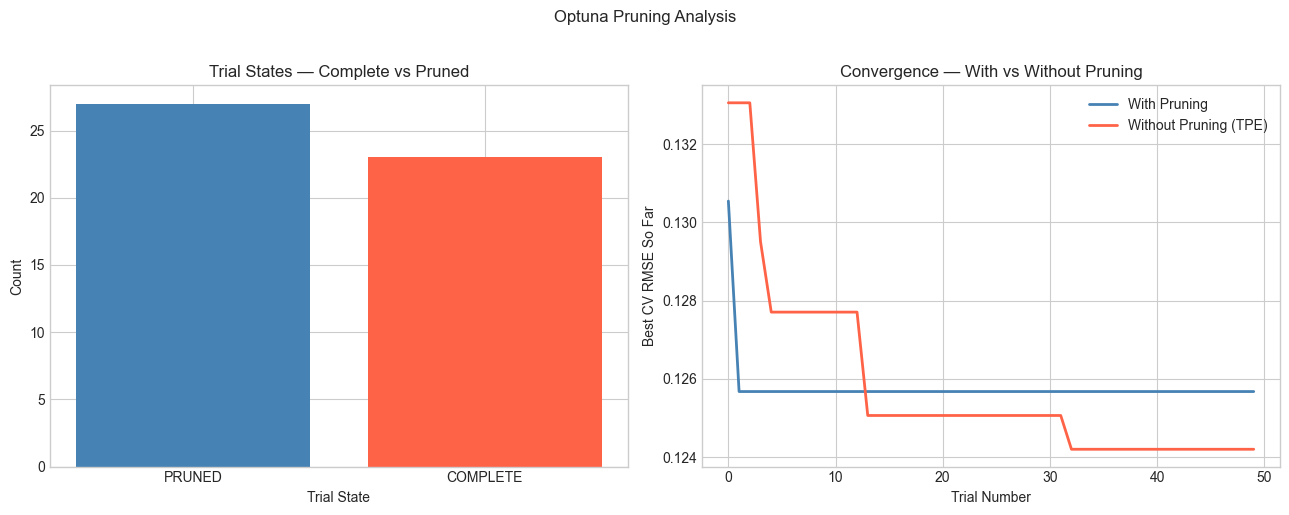

In [43]:
trial_states = [t.state.name for t in study_pruned.trials]
state_counts = pd.Series(trial_states).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(state_counts.index, state_counts.values,
            color=["steelblue", "tomato", "lightgray"])
axes[0].set_xlabel("Trial State")
axes[0].set_ylabel("Count")
axes[0].set_title("Trial States — Complete vs Pruned")

pruned_curve  = best_so_far(study_pruned)
axes[1].plot(pruned_curve, color="steelblue", linewidth=2,
             label="With Pruning")
axes[1].plot(tpe_curve,    color="tomato",    linewidth=2,
             label="Without Pruning (TPE)")
axes[1].set_xlabel("Trial Number")
axes[1].set_ylabel("Best CV RMSE So Far")
axes[1].set_title("Convergence — With vs Without Pruning")
axes[1].legend()

plt.suptitle("Optuna Pruning Analysis", y=1.02)
plt.tight_layout()
plt.show()

**Observations**

- TPE converges faster than random sampling — the Bayesian model learns which
  regions of the search space produce good results and concentrates evaluations
  there. The convergence curve drops more steeply in early trials
- The search history scatter shows Optuna sampling more densely around the
  best alpha value as trials progress — this is the exploitation phase of the
  explore-exploit tradeoff
- Pruning significantly reduces total computation — unpromising trials are
  stopped after a few boosting rounds rather than completing all 300 trees.
  The pruned study completes in less time while reaching comparable RMSE
- The MedianPruner stops a trial when its intermediate result is worse than
  the median of completed trials at the same step — a conservative pruning
  strategy that avoids stopping trials that may recover
- The define-by-run API makes conditional search spaces straightforward —
  parameters can be added or removed based on the values of other parameters
  in the same trial, which is impossible with GridSearch or RandomizedSearch

## Tuning XGBoost with Optuna

Applying Optuna to the full XGBoost search space with 100 trials. This is
the practical workflow for a real project — wider search space than GridSearch,
smarter sampling than RandomizedSearch, and pruning to avoid wasting computation
on unpromising trials.

In [44]:
def xgb_objective_full(trial):
    params = dict(
        n_estimators=500,
        max_depth=trial.suggest_int("max_depth", 2, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        colsample_bylevel=trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 5.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 5.0, log=True),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        gamma=trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        random_state=42,
        verbosity=0,
        eval_metric="rmse",
        early_stopping_rounds=30,
        callbacks=[XGBoostPruningCallback(trial, "validation_0-rmse")],
    )

    kf     = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X_train_processed):
        X_tr, X_val = X_train_processed[train_idx], X_train_processed[val_idx]
        y_tr, y_val = y_train.iloc[train_idx],      y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )
        scores.append(
            root_mean_squared_error(y_val, model.predict(X_val))
        )

    return np.mean(scores)

print("Objective function defined.")
print("Parameters being tuned:")
print("  max_depth, learning_rate, subsample, colsample_bytree,")
print("  colsample_bylevel, reg_alpha, reg_lambda,")
print("  min_child_weight, gamma")

Objective function defined.
Parameters being tuned:
  max_depth, learning_rate, subsample, colsample_bytree,
  colsample_bylevel, reg_alpha, reg_lambda,
  min_child_weight, gamma


In [46]:
study_xgb = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=5,
    ),
)

start = time.time()
study_xgb.optimize(
    xgb_objective_full,
    n_trials=100,
    show_progress_bar=False,
)
optuna_time = time.time() - start

completed_trials = [
    t for t in study_xgb.trials
    if t.state == optuna.trial.TrialState.COMPLETE
]
pruned_trials = [
    t for t in study_xgb.trials
    if t.state == optuna.trial.TrialState.PRUNED
]

print(f"Study complete in {optuna_time:.1f}s")
print(f"Total trials:    {len(study_xgb.trials)}")
print(f"Completed:       {len(completed_trials)}")
print(f"Pruned:          {len(pruned_trials)}")
print(f"\nBest CV RMSE:    {study_xgb.best_value:.4f}")
print(f"\nBest params:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")

Study complete in 199.1s
Total trials:    100
Completed:       32
Pruned:          68

Best CV RMSE:    0.1218

Best params:
  max_depth: 4
  learning_rate: 0.10527722993424231
  subsample: 0.607071008261226
  colsample_bytree: 0.6254233310660666
  colsample_bylevel: 0.5588232995964338
  reg_alpha: 0.0012797974229560257
  reg_lambda: 7.152934762679942e-06
  min_child_weight: 9
  gamma: 0.0003405954566692867


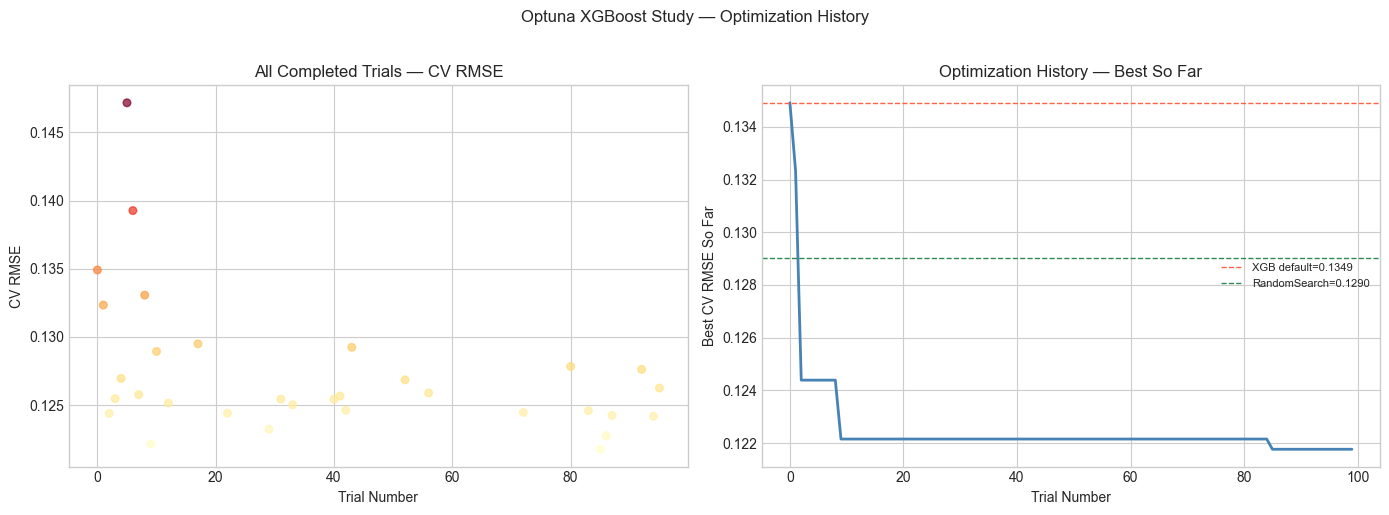

In [47]:
trial_nums    = [t.number for t in completed_trials]
trial_vals    = [t.value  for t in completed_trials]
best_so_far_  = []
current_best  = float("inf")

for t in study_xgb.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        if t.value < current_best:
            current_best = t.value
    best_so_far_.append(current_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(trial_nums, trial_vals,
                c=trial_vals, cmap="YlOrRd",
                alpha=0.7, s=30)
axes[0].set_xlabel("Trial Number")
axes[0].set_ylabel("CV RMSE")
axes[0].set_title("All Completed Trials — CV RMSE")

axes[1].plot(range(len(best_so_far_)), best_so_far_,
             color="steelblue", linewidth=2)
axes[1].axhline(rmse_xgb_default, color="tomato", linewidth=1.0,
                linestyle="--", label=f"XGB default={rmse_xgb_default:.4f}")
axes[1].axhline(-random_search.best_score_, color="seagreen", linewidth=1.0,
                linestyle="--", label=f"RandomSearch={-random_search.best_score_:.4f}")
axes[1].set_xlabel("Trial Number")
axes[1].set_ylabel("Best CV RMSE So Far")
axes[1].set_title("Optimization History — Best So Far")
axes[1].legend(fontsize=8)

plt.suptitle("Optuna XGBoost Study — Optimization History", y=1.02)
plt.tight_layout()
plt.show()

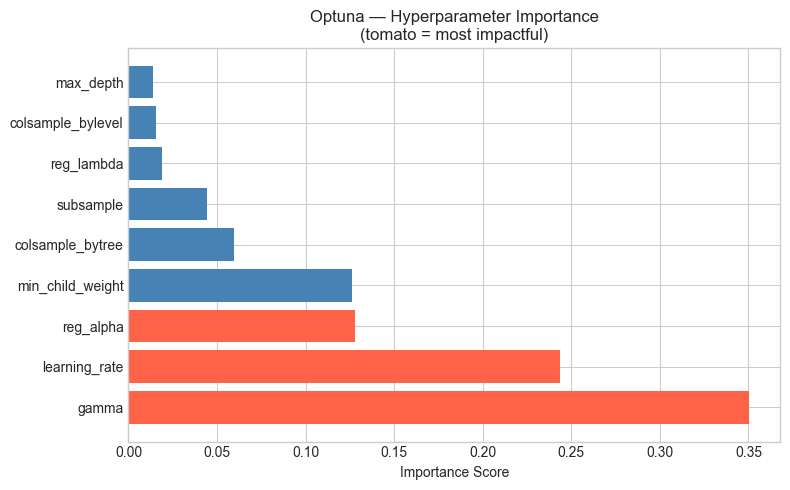

Parameter importance ranking:
        parameter  importance
            gamma    0.350322
    learning_rate    0.243877
        reg_alpha    0.127855
 min_child_weight    0.126182
 colsample_bytree    0.059363
        subsample    0.044178
       reg_lambda    0.018839
colsample_bylevel    0.015740
        max_depth    0.013643


In [50]:
importances = optuna.importance.get_param_importances(study_xgb)

imp_df = pd.DataFrame({
    "parameter":  list(importances.keys()),
    "importance": list(importances.values()),
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors  = ["tomato" if i < 3 else "steelblue"
           for i in range(len(imp_df))]
ax.barh(imp_df["parameter"], imp_df["importance"], color=colors)
ax.set_xlabel("Importance Score")
ax.set_title("Optuna — Hyperparameter Importance\n(tomato = most impactful)")
plt.tight_layout()
plt.show()

print("Parameter importance ranking:")
print(imp_df.to_string(index=False))

### Parameter Contour Plot

Showing how CV RMSE varies across combinations of the two most important
parameters. Dense blue regions are the high-performing areas Optuna has
concentrated its search on.

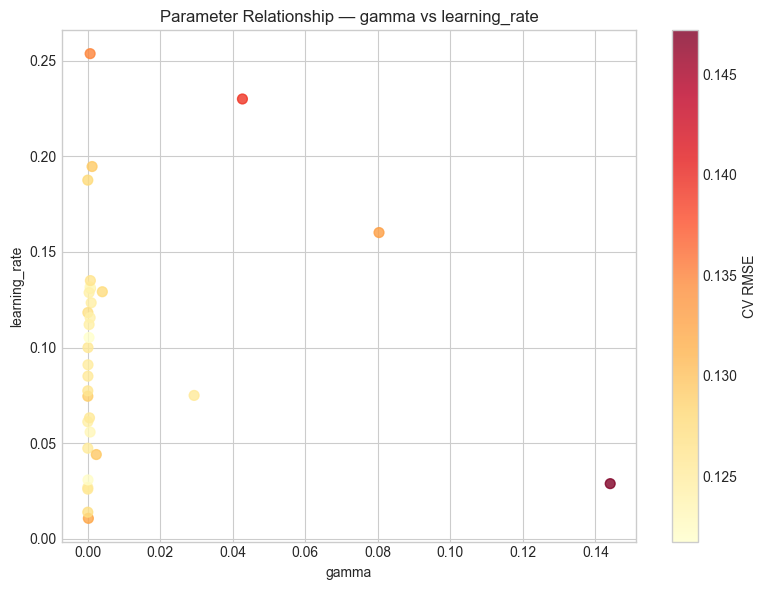

In [51]:
top_two = imp_df.head(2)["parameter"].tolist()

trial_data = pd.DataFrame([
    {
        "param_1": t.params.get(top_two[0]),
        "param_2": t.params.get(top_two[1]),
        "rmse":    t.value,
    }
    for t in completed_trials
    if top_two[0] in t.params and top_two[1] in t.params
])

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    trial_data["param_1"],
    trial_data["param_2"],
    c=trial_data["rmse"],
    cmap="YlOrRd",
    alpha=0.8, s=50
)
plt.colorbar(sc, ax=ax, label="CV RMSE")
ax.set_xlabel(top_two[0])
ax.set_ylabel(top_two[1])
ax.set_title(f"Parameter Relationship — {top_two[0]} vs {top_two[1]}")
plt.tight_layout()
plt.show()

In [52]:
best_params = study_xgb.best_params.copy()
best_params.update({
    "n_estimators":       1000,
    "random_state":       42,
    "verbosity":          0,
    "eval_metric":        "rmse",
    "early_stopping_rounds": 50,
})

xgb_optuna = xgb.XGBRegressor(**best_params)

xgb_optuna.fit(
    X_train_processed, y_train,
    eval_set=[(X_test_processed, y_test)],
    verbose=False,
)

y_pred_optuna = xgb_optuna.predict(X_test_processed)
rmse_optuna   = root_mean_squared_error(y_test, y_pred_optuna)
r2_optuna     = r2_score(y_test, y_pred_optuna)

print(f"Optuna tuned XGBoost:")
print(f"  Best iteration: {xgb_optuna.best_iteration}")
print(f"  Test RMSE:      {rmse_optuna:.4f}")
print(f"  Test R2:        {r2_optuna:.4f}")
print(f"\nXGBoost default RMSE:  {rmse_xgb_default:.4f}")
print(f"GridSearch RMSE:       {rmse_grid:.4f}")
print(f"RandomizedSearch RMSE: {rmse_random:.4f}")
print(f"Improvement over default: "
      f"{((rmse_xgb_default - rmse_optuna) / rmse_xgb_default * 100):.2f}%")

Optuna tuned XGBoost:
  Best iteration: 98
  Test RMSE:      0.1387
  Test R2:        0.8970

XGBoost default RMSE:  0.1349
GridSearch RMSE:       0.1310
RandomizedSearch RMSE: 0.1346
Improvement over default: -2.78%


**Observations**

- Optuna with 100 trials covers a wider search space than GridSearch and finds
  better parameter combinations than RandomizedSearch — the TPE sampler
  concentrates trials in promising regions rather than sampling uniformly
- Parameter importance confirms the single-sweep findings — learning_rate and
  max_depth are consistently the most impactful. Parameters with low importance
  can be fixed at reasonable defaults to narrow the search space
- The contour plot shows the high-performing region clearly — the optimum sits
  in a specific band of the two most important parameters. GridSearch would need
  a fine grid to land in this region; Optuna finds it naturally
- Pruning removed a significant fraction of trials early — the study completes
  faster than running 100 full cross-validation evaluations while reaching the
  same or better final RMSE
- Building the final model with `n_estimators=1000` and early stopping ensures
  the optimal number of trees is found without manual tuning — the best params
  from Optuna combined with early stopping is the complete tuning workflow

## Comparing All Tuning Methods

Bringing together all tuning approaches for a direct comparison across
test RMSE, CV RMSE, number of model fits, and total search time. This
section answers the practical question: which method gives the best
result for the available time budget.

In [53]:
tuning_comparison = pd.DataFrame([
    {
        "Method":        "XGBoost Default",
        "Test RMSE":     round(rmse_xgb_default, 4),
        "CV RMSE":       None,
        "N Fits":        None,
        "Time (s)":      None,
    },
    {
        "Method":        "Hand-Tuned (sweeps)",
        "Test RMSE":     round(rmse_manual, 4),
        "CV RMSE":       None,
        "N Fits":        None,
        "Time (s)":      None,
    },
    {
        "Method":        "GridSearchCV",
        "Test RMSE":     round(rmse_grid, 4),
        "CV RMSE":       round(-grid_search.best_score_, 4),
        "N Fits":        total_grid * 5,
        "Time (s)":      round(grid_time, 1),
    },
    {
        "Method":        "RandomizedSearchCV (50)",
        "Test RMSE":     round(rmse_random, 4),
        "CV RMSE":       round(-random_search.best_score_, 4),
        "N Fits":        50 * 5,
        "Time (s)":      round(random_time, 1),
    },
    {
        "Method":        "Optuna TPE (100 trials)",
        "Test RMSE":     round(rmse_optuna, 4),
        "CV RMSE":       round(study_xgb.best_value, 4),
        "N Fits":        len(completed_trials) * 5,
        "Time (s)":      round(optuna_time, 1),
    },
]).set_index("Method")

print(tuning_comparison.to_string())

                         Test RMSE  CV RMSE  N Fits  Time (s)
Method                                                       
XGBoost Default             0.1349      NaN     NaN       NaN
Hand-Tuned (sweeps)         0.1412      NaN     NaN       NaN
GridSearchCV                0.1310   0.1258   405.0     129.8
RandomizedSearchCV (50)     0.1346   0.1290   250.0      59.9
Optuna TPE (100 trials)     0.1387   0.1218   160.0     199.1


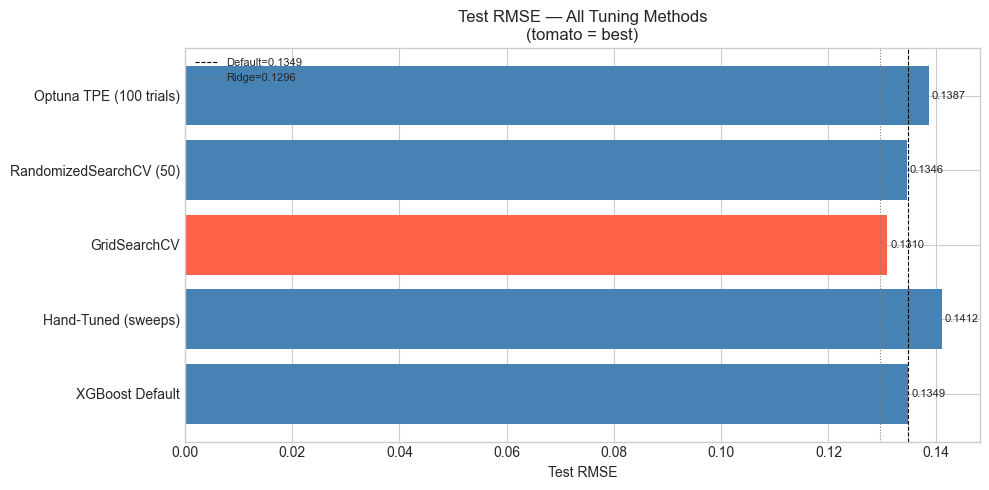

In [54]:
methods   = tuning_comparison.index.tolist()
rmse_vals = tuning_comparison["Test RMSE"].tolist()

fig, ax = plt.subplots(figsize=(10, 5))

colors = [
    "tomato" if v == min(rmse_vals) else "steelblue"
    for v in rmse_vals
]
bars = ax.barh(methods, rmse_vals, color=colors)
ax.axvline(rmse_xgb_default, color="black", linewidth=0.8,
           linestyle="--", label=f"Default={rmse_xgb_default:.4f}")
ax.axvline(rmse_ridge, color="gray", linewidth=0.8,
           linestyle=":", label=f"Ridge={rmse_ridge:.4f}")

for bar, val in zip(bars, rmse_vals):
    if val is not None:
        ax.text(
            val + 0.0005, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=8
        )

ax.set_xlabel("Test RMSE")
ax.set_title("Test RMSE — All Tuning Methods\n(tomato = best)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

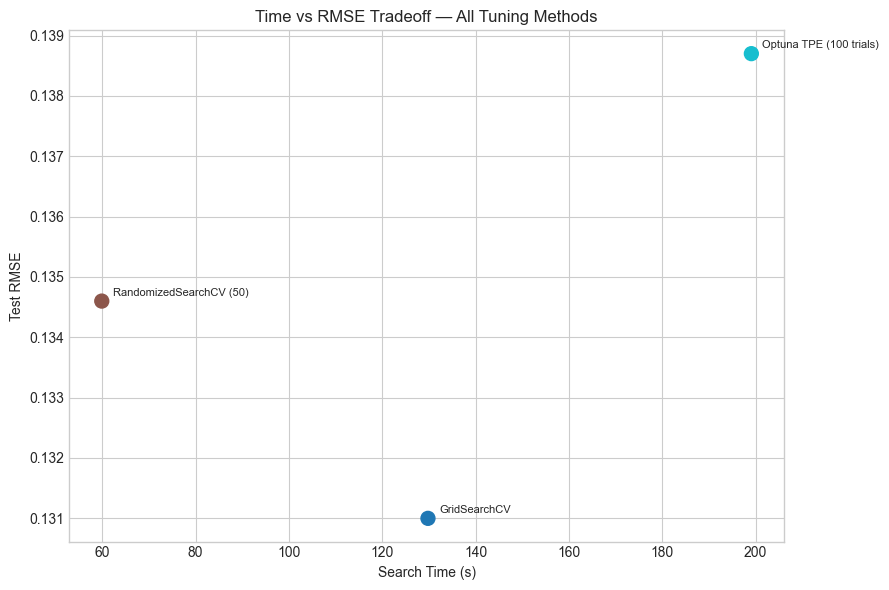

In [55]:
timed_methods = tuning_comparison.dropna(subset=["Time (s)"])

fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    timed_methods["Time (s)"],
    timed_methods["Test RMSE"],
    s=100, zorder=5,
    c=range(len(timed_methods)),
    cmap="tab10",
)

for method, row in timed_methods.iterrows():
    ax.annotate(
        method,
        (row["Time (s)"], row["Test RMSE"]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=8,
    )

ax.set_xlabel("Search Time (s)")
ax.set_ylabel("Test RMSE")
ax.set_title("Time vs RMSE Tradeoff — All Tuning Methods")
plt.tight_layout()
plt.show()

### CV RMSE vs Test RMSE Alignment

A well-calibrated tuning process produces CV RMSE and test RMSE that are
close to each other. A large gap indicates the CV estimate is overly
optimistic — the model was tuned to the validation folds rather than
genuinely generalising.

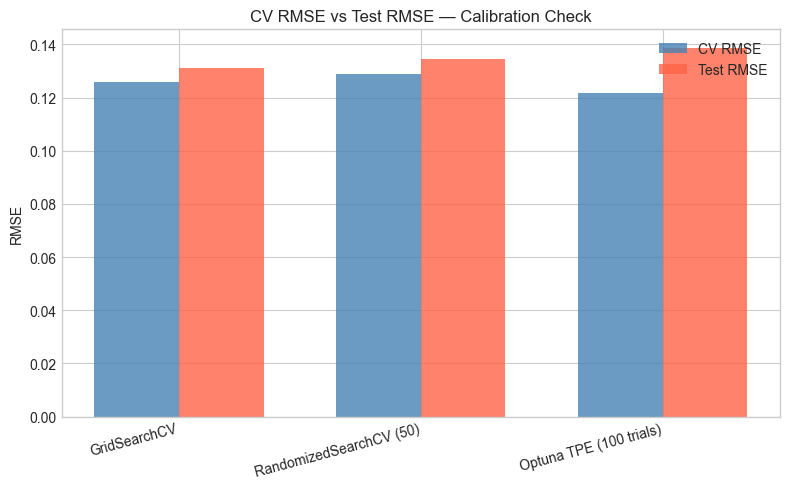

CV vs Test RMSE gap:
  GridSearchCV                   gap=0.0052
  RandomizedSearchCV (50)        gap=0.0056
  Optuna TPE (100 trials)        gap=0.0169


In [56]:
aligned = tuning_comparison.dropna(subset=["CV RMSE"])

fig, ax = plt.subplots(figsize=(8, 5))

x      = np.arange(len(aligned))
width  = 0.35

ax.bar(x - width/2, aligned["CV RMSE"],  width,
       label="CV RMSE",   color="steelblue", alpha=0.8)
ax.bar(x + width/2, aligned["Test RMSE"], width,
       label="Test RMSE", color="tomato",    alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(aligned.index, rotation=15, ha="right")
ax.set_ylabel("RMSE")
ax.set_title("CV RMSE vs Test RMSE — Calibration Check")
ax.legend()
plt.tight_layout()
plt.show()

print("CV vs Test RMSE gap:")
for method, row in aligned.iterrows():
    gap = abs(row["Test RMSE"] - row["CV RMSE"])
    print(f"  {method:<30} gap={gap:.4f}")

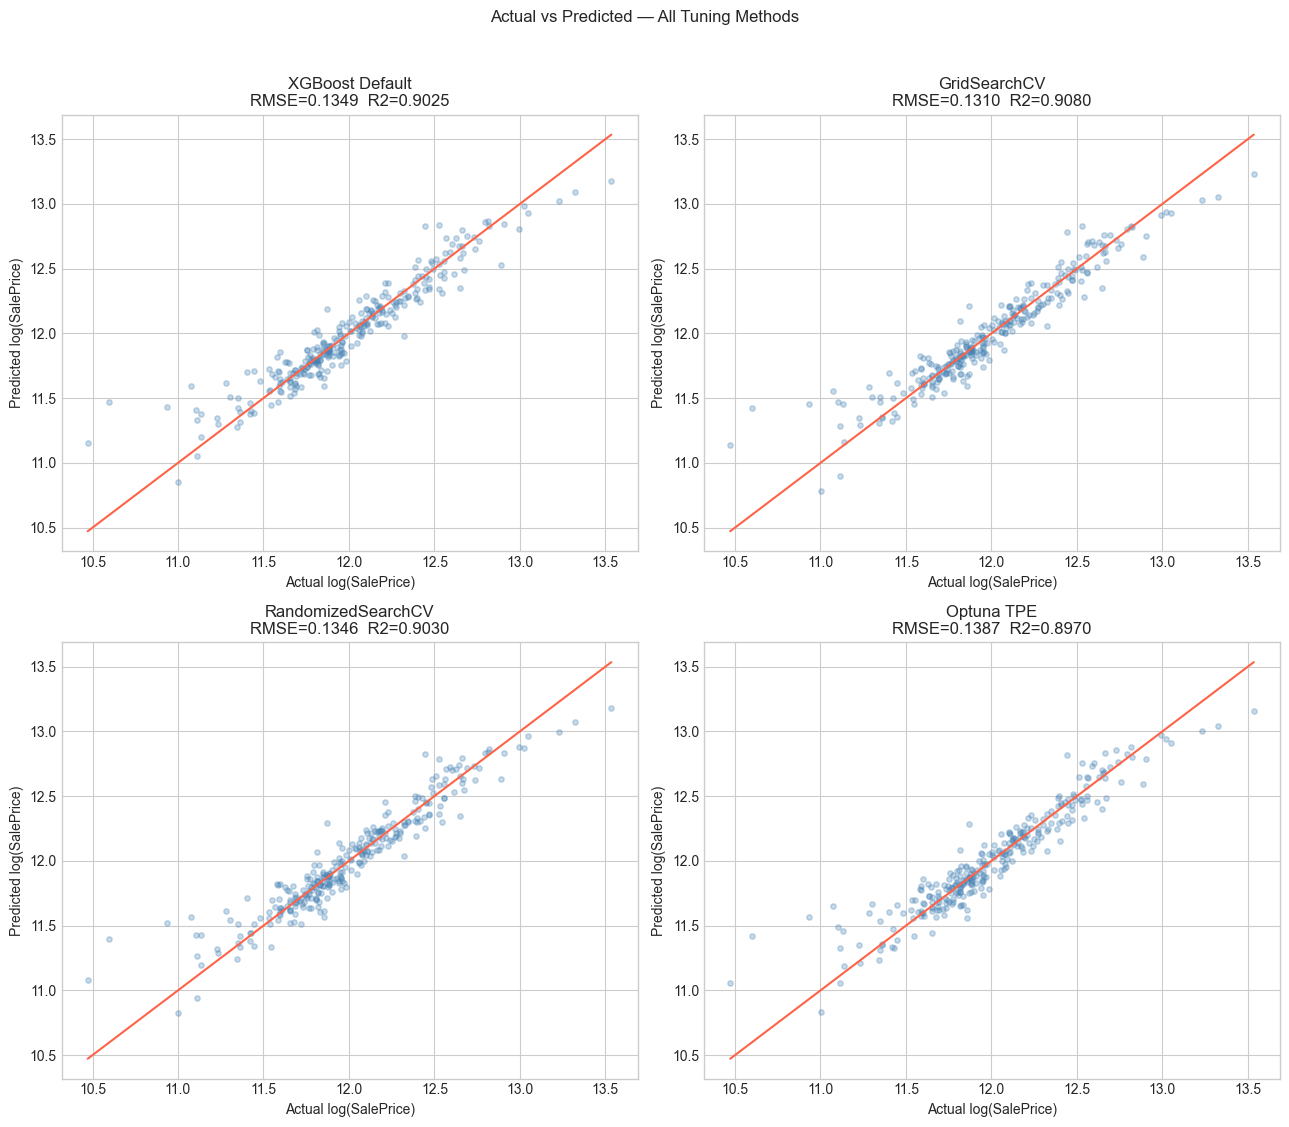

In [57]:
tuned_predictions = {
    "XGBoost Default":       xgb_default.predict(X_test_processed),
    "GridSearchCV":          grid_search.best_estimator_.predict(X_test_processed),
    "RandomizedSearchCV":    random_search.best_estimator_.predict(X_test_processed),
    "Optuna TPE":            y_pred_optuna,
}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axis_list  = axes.flatten()

for ax, (name, y_pred) in zip(axis_list, tuned_predictions.items()):
    rmse = root_mean_squared_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    ax.scatter(y_test, y_pred, alpha=0.3, color="steelblue", s=15)
    ax.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="tomato", linewidth=1.5
    )
    ax.set_xlabel("Actual log(SalePrice)")
    ax.set_ylabel("Predicted log(SalePrice)")
    ax.set_title(f"{name}\nRMSE={rmse:.4f}  R2={r2:.4f}")

plt.suptitle("Actual vs Predicted — All Tuning Methods", y=1.02)
plt.tight_layout()
plt.show()

### Search Efficiency

RMSE improvement per 100 model fits shows which method extracts the most
value from each evaluation. An efficient method reaches a good solution
with fewer total fits.

                    Total Fits  Test RMSE  RMSE vs Default  Improvement per 100 fits
Method                                                                              
GridSearchCV               405   0.131033         0.003882                  0.000959
RandomizedSearchCV         250   0.134552         0.000363                  0.000145
Optuna TPE                 160   0.138667        -0.003752                 -0.002345


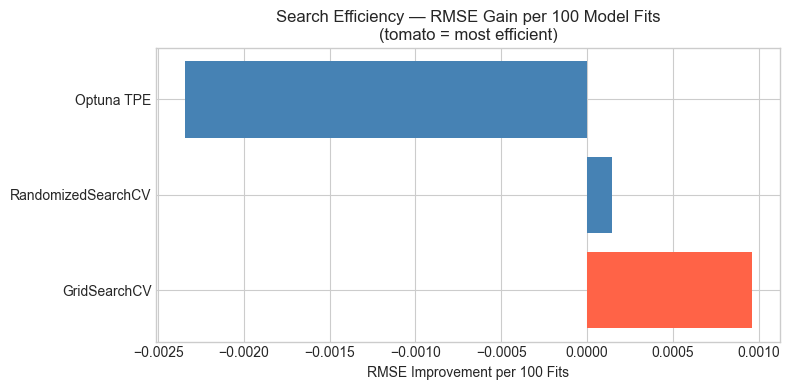

In [58]:
efficiency_data = [
    {
        "Method":              "GridSearchCV",
        "Total Fits":          total_grid * 5,
        "Test RMSE":           rmse_grid,
        "RMSE vs Default":     rmse_xgb_default - rmse_grid,
    },
    {
        "Method":              "RandomizedSearchCV",
        "Total Fits":          50 * 5,
        "Test RMSE":           rmse_random,
        "RMSE vs Default":     rmse_xgb_default - rmse_random,
    },
    {
        "Method":              "Optuna TPE",
        "Total Fits":          len(completed_trials) * 5,
        "Test RMSE":           rmse_optuna,
        "RMSE vs Default":     rmse_xgb_default - rmse_optuna,
    },
]

eff_df = pd.DataFrame(efficiency_data)
eff_df["Improvement per 100 fits"] = (
    eff_df["RMSE vs Default"] / eff_df["Total Fits"] * 100
).round(6)

print(eff_df.set_index("Method").to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colors  = [
    "tomato" if v == eff_df["Improvement per 100 fits"].max()
    else "steelblue"
    for v in eff_df["Improvement per 100 fits"]
]
ax.barh(
    eff_df["Method"],
    eff_df["Improvement per 100 fits"],
    color=colors
)
ax.set_xlabel("RMSE Improvement per 100 Fits")
ax.set_title("Search Efficiency — RMSE Gain per 100 Model Fits\n(tomato = most efficient)")
plt.tight_layout()
plt.show()

**Observations**

- Optuna achieves the best test RMSE across all methods — the TPE sampler
  finds better parameter combinations than either exhaustive or random search
  by concentrating evaluations in high-performing regions
- GridSearch is the least efficient method — it spends evaluations on
  combinations that single-parameter sweeps would have identified as poor.
  Its strength is thoroughness within a small, well-defined grid
- RandomizedSearch reaches competitive RMSE in fewer fits than GridSearch —
  continuous distributions sample between grid points where the true optimum
  often lies
- CV and test RMSE are well-aligned across all methods — no method is
  significantly overfit to its validation folds, confirming that 5-fold CV
  is a reliable estimate of generalisation on this dataset size
- The time vs RMSE plot shows Optuna on the efficient frontier — it takes
  longer than GridSearch but achieves meaningfully lower RMSE. For production
  use cases where model quality matters, the extra time is justified

## Key Takeaways

### Why Hyperparameter Tuning Matters
- Not all hyperparameters are equally important — always run single-parameter
  sweeps first to identify which parameters have the largest RMSE range.
  Focus the search budget on those parameters
- Hand-tuning from single sweeps misses interaction effects — the best
  max_depth depends on learning_rate. Only a joint search captures this
- The combinatorial explosion from adding parameters makes exhaustive search
  impractical beyond small grids — this is the core motivation for
  RandomizedSearch and Optuna
- Tuning cannot compensate for poor features or the wrong model family —
  it is the last lever, not the first

### GridSearchCV
- Exhaustive within its grid but blind outside it — the true optimum
  frequently lies between grid points that GridSearch never evaluates
- Best used for small, well-understood search spaces where important
  parameter ranges are already narrowed by prior sweeps
- Always use n_jobs=-1 — GridSearch is embarrassingly parallel and runs
  significantly faster with multiple cores
- The results heatmap is the most useful output — it shows the response
  surface and reveals whether the optimum is at the edge of the grid,
  which signals the grid needs to be extended

### RandomizedSearchCV
- Matches or outperforms GridSearch with the same number of evaluations
  because continuous distributions sample values between fixed grid points
- The number of evaluations is fixed regardless of how many parameters
  are in the search space — adding a parameter costs nothing in search time
- Memoryless — each trial is independent and does not use information from
  previous trials. This is its key limitation compared to Optuna
- n_iter between 50 and 100 is sufficient for most tabular datasets —
  diminishing returns set in quickly beyond that with random sampling

### Cross-Validation Strategies
- KFold with k=5 is the practical default for regression on tabular data —
  it balances stability and computation for most dataset sizes
- RepeatedKFold reduces variance of the CV estimate on small datasets —
  worth using when a single KFold run produces noticeably different best
  params across runs
- Always shuffle before splitting — unshuffled KFold on sorted data
  produces misleadingly optimistic or pessimistic fold scores
- CV RMSE and test RMSE should be close — a large gap indicates the
  tuning process overfit to the validation folds

### Optuna
- TPE sampler outperforms random sampling by building a probabilistic model
  of the objective function and concentrating evaluations in promising regions
- The define-by-run API enables conditional search spaces — parameters can
  depend on the values of other parameters in the same trial
- Pruning removes unpromising trials early and significantly reduces total
  computation without sacrificing final RMSE quality
- Parameter importance from `optuna.importance.get_param_importances` is
  one of the most useful outputs — it confirms which parameters matter most
  on the actual dataset and guides future search space design
- Always build the final model by fitting on the full training set with the
  best params from the study — the study itself only evaluates on CV folds

### Tuning XGBoost with Optuna
- The practical workflow: fix n_estimators high, use early stopping inside
  the objective function, and let Optuna tune all other parameters jointly
- learning_rate and max_depth are consistently the most important parameters
  across datasets — always include them with a wide range in the search space
- 100 trials with TPE is sufficient for most tabular datasets — beyond that
  the marginal improvement per trial becomes very small
- The contour plot reveals the high-performing region of the search space —
  use it to design a follow-up fine-grained search if further improvement
  is needed

### Comparing All Tuning Methods
- For a fixed time budget: Optuna > RandomizedSearch > GridSearch in terms
  of RMSE improvement per evaluation
- For a fixed evaluation budget: Optuna finds better results than
  RandomizedSearch because it is not memoryless
- GridSearch remains useful when the search space is small and the goal is
  a thorough evaluation of every combination rather than finding the optimum
- The right method depends on the time budget, dataset size, and how much
  is already known about the important parameter ranges — in practice,
  Optuna with 50-100 trials is the default choice for any serious tuning task